# Aufgabe 4a: Daten laden und Qualitätskontrolle

Dieses Notebook prüft zunächst nur, ob die Daten für den Klassifikationsvergleich korrekt und reproduzierbar eingelesen werden. Es verändert keine FCS-Dateien.

Für den papernahen Hauptvergleich wird `gated_alive` verwendet: lebende, von Doubletten bereinigte PBMCs ohne zusätzliches NK-Gate. Der Datensatz ist bereits vorverarbeitet und gegatet. Deshalb beschränkt sich die Qualitätskontrolle zunächst auf Spender- und Zellzahlen, Marker-Konsistenz sowie fehlende oder ungültige Werte. Eine zusätzliche Vorverarbeitung wird erst nach der späteren Kontrolle der Marker-Verteilungen erwogen.

## 1. Konfiguration und Datenpfade

Die Analyse verwendet die 37 Marker aus `NK_markers.csv`. Technische Kanäle wie `Time`, `Cell_length`, `Dead`, `DNA1` und `DNA2` gehen nicht in die Klassifikation ein.

In [1]:
from pathlib import Path
import csv
import warnings

import flowkit as fk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import StratifiedKFold

GATE = "gated_alive"
COFACTOR = 5.0
PREVIEW_DONOR = "a_001"
PREVIEW_ROWS = 5
PREVIEW_MARKERS = ["CD3", "CD4", "CD8", "CD57", "NKG2C", "CD56"]
QC_CELLS_PER_DONOR = 2_000
QC_SEED = 12_345
OUTER_SPLIT_COUNT = 100
OUTER_TRAIN_PER_CLASS = 7
INNER_FOLD_COUNT = 3
SPLIT_MASTER_SEED = 12_345

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "NK_cell_dataset").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "NK_cell_dataset" / "NK_cell_dataset"
FCS_DIR = DATA_ROOT / "NK_cell_dataset" / GATE
LABELS_PATH = DATA_ROOT / "NK_fcs_samples_with_labels.csv"
MARKERS_PATH = DATA_ROOT / "NK_markers.csv"
SPLITS_PATH = PROJECT_ROOT / "results" / "tables" / "task4_donor_splits.csv"

for required_path in (FCS_DIR, LABELS_PATH, MARKERS_PATH):
    if not required_path.exists():
        raise FileNotFoundError(f"Erwarteter Datenpfad fehlt: {required_path}")

print("Projektordner: .")
print(f"FCS-Ordner:    {FCS_DIR.relative_to(PROJECT_ROOT)}")

Projektordner: .
FCS-Ordner:    NK_cell_dataset/NK_cell_dataset/NK_cell_dataset/gated_alive


## 2. Labels, Marker und FCS-Dateien zuordnen

Die Labeldatei nennt die Dateien aus `gated_NK`. Für `gated_alive` wird daher die gemeinsame Spender-ID aus den Dateinamen extrahiert. Die folgenden Prüfungen stellen eine eindeutige Eins-zu-eins-Zuordnung sicher.

In [2]:
label_table = pd.read_csv(LABELS_PATH)
required_label_columns = {"fcs_filename", "label"}
if not required_label_columns.issubset(label_table.columns):
    raise ValueError(f"Labelspalten fehlen: {required_label_columns - set(label_table.columns)}")

label_table = label_table.loc[:, ["fcs_filename", "label"]].copy()
label_table["donor_id"] = label_table["fcs_filename"].str.replace(
    r"_NK\.fcs$", "", regex=True
)
label_table["label"] = label_table["label"].astype(int)
label_table["clinical_group"] = label_table["label"].map({0: "CMV−", 1: "CMV+"})

with MARKERS_PATH.open(newline="", encoding="utf-8-sig") as stream:
    markers = next(csv.reader(stream))

fcs_paths = sorted(FCS_DIR.glob("*.fcs"))
fcs_table = pd.DataFrame(
    {
        "donor_id": [path.stem.removesuffix("_alive") for path in fcs_paths],
        "fcs_path": fcs_paths,
    }
)

if not label_table["donor_id"].is_unique:
    raise ValueError("Die Labeldatei enthält doppelte Spender-IDs.")
if not fcs_table["donor_id"].is_unique:
    raise ValueError(f"Der Ordner {GATE} enthält doppelte Spender-IDs.")
if set(label_table["donor_id"]) != set(fcs_table["donor_id"]):
    raise ValueError("Spender-IDs in Labeldatei und FCS-Ordner stimmen nicht überein.")
if len(markers) != len(set(markers)):
    raise ValueError("Die Markerdatei enthält doppelte Markernamen.")

sample_table = (
    label_table.merge(fcs_table, on="donor_id", validate="one_to_one")
    .sort_values("donor_id")
    .reset_index(drop=True)
)

assert len(sample_table) == 20
assert sample_table["label"].value_counts().sort_index().to_dict() == {0: 11, 1: 9}
assert len(markers) == 37

dataset_overview = pd.Series(
    {
        "Gate": GATE,
        "Spender": len(sample_table),
        "CMV−": int((sample_table["label"] == 0).sum()),
        "CMV+": int((sample_table["label"] == 1).sum()),
        "Analysemarker": len(markers),
    },
    name="Wert",
).to_frame()

display(dataset_overview)
sample_display = sample_table[["donor_id", "clinical_group"]].copy()
sample_display["fcs_file"] = sample_table["fcs_path"].map(
    lambda path: str(path.relative_to(PROJECT_ROOT))
)
display(sample_display)

,Wert
Gate,gated_alive
Spender,20
CMV−,11
CMV+,9
Analysemarker,37


,donor_id,clinical_group,fcs_file
0,a_001,CMV+,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
1,a_002,CMV+,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
2,a_003,CMV−,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
3,a_004,CMV−,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
4,a_005,CMV+,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
5,a_006,CMV−,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
6,a_007,CMV+,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
7,a_009,CMV−,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
8,a_010,CMV−,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...
9,a_011,CMV−,NK_cell_dataset/NK_cell_dataset/NK_cell_datase...


## 3. FCS-Dateien kontrolliert laden

Die Originaldateien melden im FCS-Header einen Datenoffset, der um ein Byte abweicht. FlowKit kann diese Dateien mit `ignore_offset_error=True` lesen. Die ersten Messwerte wurden zusätzlich mit einem unabhängigen Standardbibliotheks-Leser abgeglichen. Um die beiden Varianten der Detektornamen im Datensatz korrekt zusammenzuführen, werden Marker ausschließlich über die konsistenten FCS-Kurznamen (`$PnS`) ausgewählt.

`source="raw"` verhindert eine automatische Transformation oder Kompensation. Anschließend wird explizit die papernahe Transformation `arcsinh(x / 5)` berechnet.

In [3]:
def load_fcs_sample(
    path: Path, selected_markers: list[str]
) -> tuple[np.ndarray, dict[str, str]]:
    """Lade eine FCS-Datei read-only und gib Rohmarker und Metadaten zurück."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=r"FCS file .* reported incorrect data offset.*",
        )
        sample = fk.Sample(str(path), ignore_offset_error=True)

    frame = sample.as_dataframe(source="raw")
    short_names = pd.Index(sample.pns_labels, name="marker")
    if len(short_names) != frame.shape[1]:
        raise ValueError(f"Kanalzahl und Datenspalten unterscheiden sich in {path.name}.")
    if not short_names.is_unique:
        duplicates = short_names[short_names.duplicated()].tolist()
        raise ValueError(f"Doppelte FCS-Kurznamen in {path.name}: {duplicates}")

    frame.columns = short_names
    missing_markers = [marker for marker in selected_markers if marker not in frame.columns]
    if missing_markers:
        raise ValueError(f"Fehlende Marker in {path.name}: {missing_markers}")

    raw_values = frame.loc[:, selected_markers].to_numpy(dtype=np.float32, copy=True)
    if raw_values.shape != (sample.event_count, len(selected_markers)):
        raise ValueError(
            f"Unerwartete Datenform in {path.name}: {raw_values.shape}"
        )
    fcs_metadata = {
        "measurement_date": sample.metadata.get("date", ""),
        "instrument": sample.metadata.get("cyt", ""),
    }
    return raw_values, fcs_metadata


def arcsinh_transform(values: np.ndarray, cofactor: float = COFACTOR) -> np.ndarray:
    """Wende die für den NK/CMV-Datensatz verwendete ArcSinh-Transformation an."""
    if cofactor <= 0:
        raise ValueError("Der ArcSinh-Kofaktor muss positiv sein.")
    return np.arcsinh(values / cofactor)

## 4. Standard-QC über alle Spender

Die Dateien werden nacheinander eingelesen, damit nicht alle 3,4 Millionen Zellen gleichzeitig im Arbeitsspeicher liegen. Für jeden Spender werden Form, Wertebereich und die Anzahl nicht-endlicher Werte geprüft.

In [4]:
qc_records = []
balanced_qc_parts = []
qc_rng = np.random.default_rng(QC_SEED)

for row in sample_table.itertuples(index=False):
    raw_values, fcs_metadata = load_fcs_sample(row.fcs_path, markers)
    transformed_values = arcsinh_transform(raw_values)
    sample_size = min(QC_CELLS_PER_DONOR, len(transformed_values))
    sampled_indices = qc_rng.choice(len(transformed_values), size=sample_size, replace=False)
    sampled_values = pd.DataFrame(
        transformed_values[sampled_indices],
        columns=markers,
    )
    sampled_values.insert(0, "donor_id", row.donor_id)
    balanced_qc_parts.append(sampled_values)

    qc_records.append(
        {
            "donor_id": row.donor_id,
            "label": row.label,
            "clinical_group": row.clinical_group,
            "measurement_date": fcs_metadata["measurement_date"],
            "instrument": fcs_metadata["instrument"],
            "event_count": raw_values.shape[0],
            "marker_count": raw_values.shape[1],
            "nonfinite_raw": int(raw_values.size - np.isfinite(raw_values).sum()),
            "nonfinite_transformed": int(
                transformed_values.size - np.isfinite(transformed_values).sum()
            ),
            "raw_min": float(raw_values.min()),
            "raw_max": float(raw_values.max()),
            "transformed_min": float(transformed_values.min()),
            "transformed_max": float(transformed_values.max()),
        }
    )

qc_summary = pd.DataFrame(qc_records)
balanced_qc_cells = pd.concat(balanced_qc_parts, ignore_index=True)

assert qc_summary["event_count"].sum() == 3_438_750
assert qc_summary["marker_count"].eq(37).all()
assert qc_summary["nonfinite_raw"].eq(0).all()
assert qc_summary["nonfinite_transformed"].eq(0).all()
assert balanced_qc_cells.groupby("donor_id").size().eq(QC_CELLS_PER_DONOR).all()

qc_overview = pd.Series(
    {
        "FCS-Dateien": len(qc_summary),
        "Zellen insgesamt": int(qc_summary["event_count"].sum()),
        "Marker je Datei": int(qc_summary["marker_count"].iloc[0]),
        "Nicht-endliche Rohwerte": int(qc_summary["nonfinite_raw"].sum()),
        "Nicht-endliche transformierte Werte": int(
            qc_summary["nonfinite_transformed"].sum()
        ),
        "Globales Rohwertminimum": qc_summary["raw_min"].min(),
        "Globales Rohwertmaximum": qc_summary["raw_max"].max(),
    },
    name="Wert",
).to_frame()

display(qc_overview)
display(qc_summary.round(4))

,Wert
FCS-Dateien,2.000000e+01
Zellen insgesamt,3.438750e+06
Marker je Datei,3.700000e+01
Nicht-endliche Rohwerte,0.000000e+00
Nicht-endliche transformierte Werte,0.000000e+00
Globales Rohwertminimum,-1.000000e+00
Globales Rohwertmaximum,1.671098e+04


,donor_id,label,clinical_group,measurement_date,instrument,event_count,marker_count,nonfinite_raw,nonfinite_transformed,raw_min,raw_max,transformed_min,transformed_max
0,a_001,1,CMV+,01-May-2012,DVSSCIENCES-CYTOF-5.1.559,82324,37,0,0,-1.0,12450.3057,-0.1987,8.5132
1,a_002,1,CMV+,01-May-2012,DVSSCIENCES-CYTOF-5.1.559,108267,37,0,0,-1.0,14783.9365,-0.1987,8.6850
2,a_003,0,CMV−,08-May-2012,DVSSCIENCES-CYTOF-5.1.559,97529,37,0,0,-1.0,14022.6934,-0.1987,8.6321
3,a_004,0,CMV−,08-May-2012,DVSSCIENCES-CYTOF-5.1.559,140687,37,0,0,-1.0,14986.7031,-0.1987,8.6986
4,a_005,1,CMV+,08-May-2012,DVSSCIENCES-CYTOF-5.1.559,155335,37,0,0,-1.0,13522.6113,-0.1987,8.5958
5,a_006,0,CMV−,01-May-2012,DVSSCIENCES-CYTOF-5.1.559,90075,37,0,0,-1.0,14369.7314,-0.1987,8.6566
6,a_007,1,CMV+,01-May-2012,DVSSCIENCES-CYTOF-5.1.559,104805,37,0,0,-1.0,15692.2666,-0.1987,8.7446
7,a_009,0,CMV−,01-May-2012,DVSSCIENCES-CYTOF-5.1.559,216632,37,0,0,-1.0,15753.9551,-0.1987,8.7486
8,a_010,0,CMV−,01-May-2012,DVSSCIENCES-CYTOF-5.1.559,122209,37,0,0,-1.0,11104.7949,-0.1987,8.3988
9,a_011,0,CMV−,08-May-2012,DVSSCIENCES-CYTOF-5.1.559,258461,37,0,0,-1.0,11740.4922,-0.1987,8.4545


## 5. Kleiner Kontrollausschnitt

Zur manuellen Kontrolle werden für einen Spender wenige biologisch gut interpretierbare Marker sowohl roh als auch transformiert ausgegeben. Die Zeilen entsprechen einzelnen Zellen in der Reihenfolge der FCS-Datei.

In [5]:
preview_sample = sample_table.loc[sample_table["donor_id"] == PREVIEW_DONOR].iloc[0]
preview_raw_all, preview_metadata = load_fcs_sample(preview_sample["fcs_path"], markers)
preview_indices = [markers.index(marker) for marker in PREVIEW_MARKERS]
preview_raw = pd.DataFrame(
    preview_raw_all[:PREVIEW_ROWS, preview_indices],
    columns=PREVIEW_MARKERS,
)
preview_transformed = pd.DataFrame(
    arcsinh_transform(preview_raw.to_numpy()),
    columns=PREVIEW_MARKERS,
)

print(f"Spender: {preview_sample['donor_id']}")
print(f"Gruppe:  {preview_sample['clinical_group']} (Label {preview_sample['label']})")
print(f"Messtag: {preview_metadata['measurement_date']}")
print(f"Zellen:  {len(preview_raw_all):,}".replace(",", "."))
print(f"Datenform nach Markerauswahl: {preview_raw_all.shape}")

print("Rohwerte:")
display(preview_raw.round(4))
print(f"Transformierte Werte: arcsinh(x / {COFACTOR:g})")
display(preview_transformed.round(4))

Spender: a_001
Gruppe:  CMV+ (Label 1)
Messtag: 01-May-2012
Zellen:  82.324
Datenform nach Markerauswahl: (82324, 37)
Rohwerte:


,CD3,CD4,CD8,CD57,NKG2C,CD56
0,76.489700,-0.4080,-0.977100,-0.5209,-0.1261,-0.4827
1,280.688202,13.5122,118.876801,3.4303,-0.4021,-0.6115
2,10.474300,2.0485,64.103699,1.5741,9.3015,-0.5796
3,1.998200,-0.9270,5.499800,-0.7536,-0.0151,2.8384
4,48.966702,1.8093,-0.533600,-0.9950,-0.5290,14.0939


Transformierte Werte: arcsinh(x / 5)


,CD3,CD4,CD8,CD57,NKG2C,CD56
0,3.4219,-0.0815,-0.1942,-0.1040,-0.0252,-0.0964
1,4.7210,1.7199,3.8622,0.6412,-0.0803,-0.1220
2,1.4853,0.3990,3.2457,0.3098,1.3794,-0.1157
3,0.3897,-0.1843,0.9503,-0.1502,-0.0030,0.5409
4,2.9774,0.3544,-0.1065,-0.1977,-0.1056,1.7595


## 6. Verteilungen der Analysemarker

Für diese rein deskriptive Qualitätskontrolle werden mit festem Seed 2.000 Zellen je Spender ohne Zurücklegen gezogen. Damit trägt jeder Spender gleich stark zur Darstellung bei. Die Stichprobe wird nicht zum Trainieren oder Auswählen eines Klassifikators verwendet.

Die Boxplots zeigen den Wertebereich nach `arcsinh(x / 5)`. Ausreißerpunkte werden in dieser Übersicht ausgeblendet, bleiben aber in den Daten erhalten.

Ausgewogene QC-Stichprobe: 40,000 Zellen (2,000 je Spender, Seed 12345)


,min,1%,25%,50%,75%,99%,max
CD3,-0.199,-0.174,1.959,3.594,4.777,6.415,8.447
CD27,-0.199,-0.194,-0.088,0.293,1.643,3.471,6.439
CD19,-0.199,-0.195,-0.111,-0.023,1.283,3.994,5.193
CD4,-0.199,-0.193,-0.069,0.664,2.108,4.009,5.015
CD8,-0.199,-0.189,0.212,1.642,3.127,5.336,6.225
CD57,-0.199,-0.195,-0.116,-0.032,1.196,5.068,6.830
2DL1-S1,-0.199,-0.196,-0.137,-0.074,-0.008,2.644,4.208
TRAIL,-0.199,-0.197,-0.144,-0.090,-0.036,1.651,3.581
2DL2-L3-S2,-0.199,-0.196,-0.135,-0.073,-0.011,2.532,4.261
CD16,-0.199,-0.195,-0.101,-0.002,1.725,5.383,6.571


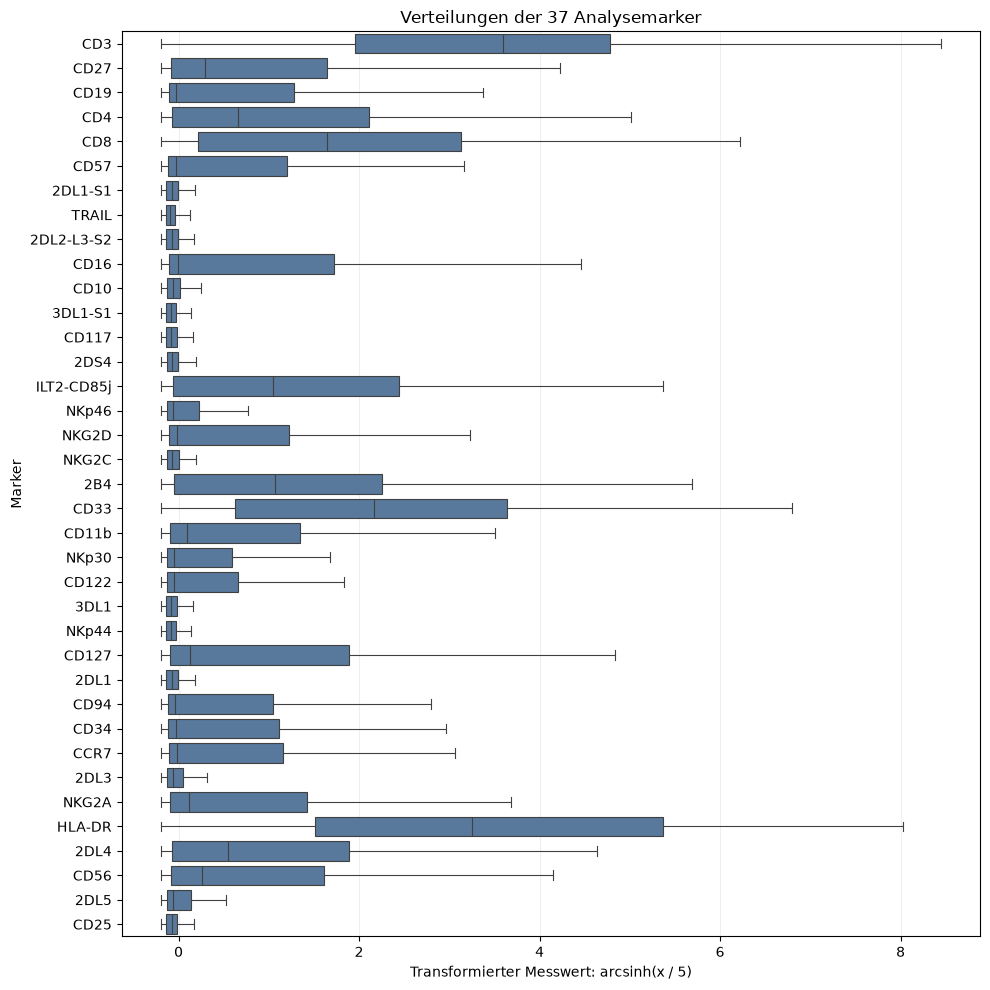

In [6]:
marker_distribution_summary = (
    balanced_qc_cells[markers]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
    .T.loc[:, ["min", "1%", "25%", "50%", "75%", "99%", "max"]]
)

print(
    f"Ausgewogene QC-Stichprobe: {len(balanced_qc_cells):,} Zellen "
    f"({QC_CELLS_PER_DONOR:,} je Spender, Seed {QC_SEED})"
)
display(marker_distribution_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 10))
sns.boxplot(
    data=balanced_qc_cells[markers],
    orient="h",
    showfliers=False,
    color="#4C78A8",
    linewidth=0.8,
    ax=ax,
)
ax.set(
    title="Verteilungen der 37 Analysemarker",
    xlabel="Transformierter Messwert: arcsinh(x / 5)",
    ylabel="Marker",
)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

## 7. Spendervergleich der Marker-Mediane

Die Heatmap dient dazu, starke spenderweite Verschiebungen einzelner Marker sichtbar zu machen. Dazu werden die Mediane der ausgewogenen QC-Stichprobe pro Marker ausschließlich für diese Abbildung robust zentriert und skaliert. Diese Visualisierungsskalierung fließt nicht in die Klassifikation ein. Die CMV-Labels werden bewusst nicht dargestellt, damit Entscheidungen zur technischen Vorverarbeitung nicht anhand des Zielwerts getroffen werden.

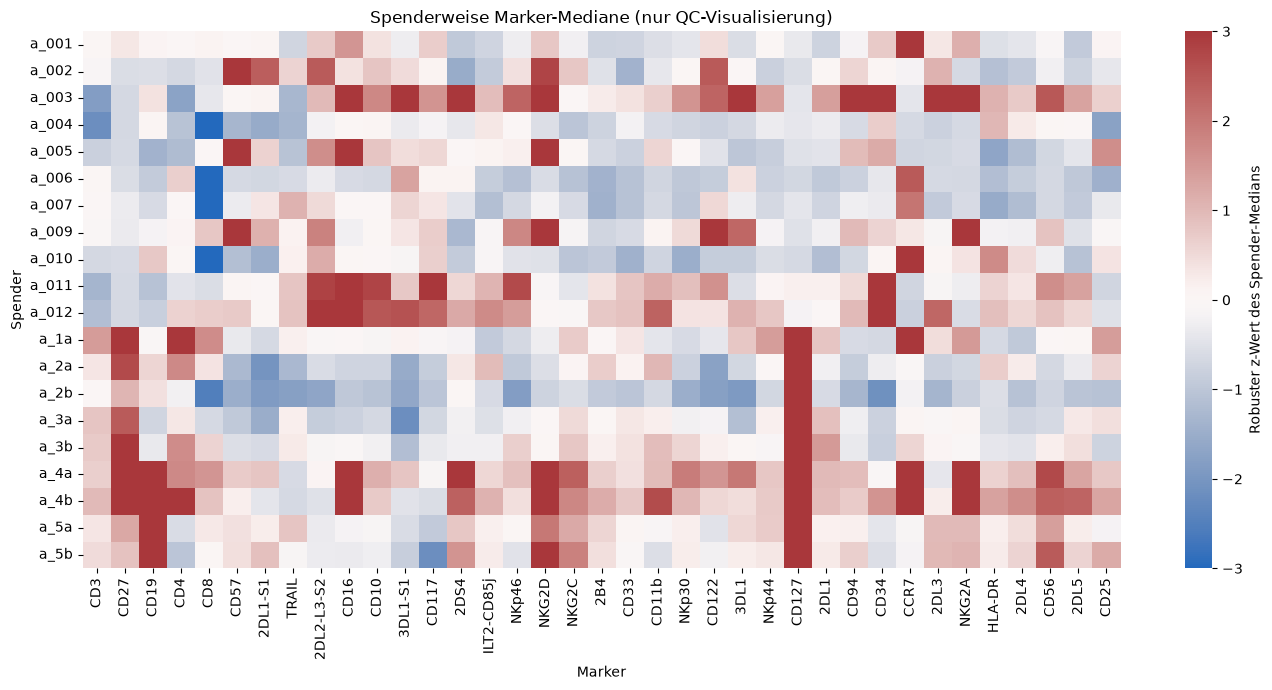

In [7]:
donor_marker_medians = balanced_qc_cells.groupby("donor_id")[markers].median()
marker_centers = donor_marker_medians.median(axis=0)
marker_mads = donor_marker_medians.sub(marker_centers).abs().median(axis=0)
zero_mad_markers = marker_mads.index[marker_mads == 0].tolist()
if zero_mad_markers:
    raise ValueError(f"Marker ohne Variation zwischen Spender-Medianen: {zero_mad_markers}")

donor_marker_robust_z = donor_marker_medians.sub(marker_centers).div(1.4826 * marker_mads)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    donor_marker_robust_z,
    cmap="vlag",
    center=0,
    vmin=-3,
    vmax=3,
    cbar_kws={"label": "Robuster z-Wert des Spender-Medians"},
    ax=ax,
)
ax.set(
    title="Spenderweise Marker-Mediane (nur QC-Visualisierung)",
    xlabel="Marker",
    ylabel="Spender",
)
fig.tight_layout()
plt.show()

## 8. Messtag und Instrumentversion

Die Heatmap zeigt teilweise blockartige Verschiebungen zwischen Spendern. Deshalb werden ergänzend Messtag und Instrumentversion aus den FCS-Metadaten betrachtet. Die Kreuztabelle dient nur zur Erkennung einer möglichen technischen Konfundierung; sie wird nicht zur Auswahl oder Entfernung einzelner Proben verwendet.

In [8]:
technical_metadata = qc_summary.loc[
    :, ["donor_id", "clinical_group", "measurement_date", "instrument"]
].copy()
batch_label_counts = pd.crosstab(
    [technical_metadata["measurement_date"], technical_metadata["instrument"]],
    technical_metadata["clinical_group"],
)

display(technical_metadata)
display(batch_label_counts)

,donor_id,clinical_group,measurement_date,instrument
0,a_001,CMV+,01-May-2012,DVSSCIENCES-CYTOF-5.1.559
1,a_002,CMV+,01-May-2012,DVSSCIENCES-CYTOF-5.1.559
2,a_003,CMV−,08-May-2012,DVSSCIENCES-CYTOF-5.1.559
3,a_004,CMV−,08-May-2012,DVSSCIENCES-CYTOF-5.1.559
4,a_005,CMV+,08-May-2012,DVSSCIENCES-CYTOF-5.1.559
5,a_006,CMV−,01-May-2012,DVSSCIENCES-CYTOF-5.1.559
6,a_007,CMV+,01-May-2012,DVSSCIENCES-CYTOF-5.1.559
7,a_009,CMV−,01-May-2012,DVSSCIENCES-CYTOF-5.1.559
8,a_010,CMV−,01-May-2012,DVSSCIENCES-CYTOF-5.1.559
9,a_011,CMV−,08-May-2012,DVSSCIENCES-CYTOF-5.1.559


,clinical_group,CMV+,CMV−
measurement_date,instrument,,
01-May-2012,DVSSCIENCES-CYTOF-5.1.559,3,3
08-May-2012,DVSSCIENCES-CYTOF-5.1.559,2,3
12-Jun-2012,DVSSCIENCES-CYTOF-5.1.562,4,5


## Vorläufige Vorverarbeitungsentscheidung

Die Dateien besitzen ein vollständiges und konsistentes Markerschema; alle ausgewählten Messwerte sind endlich. Die ArcSinh-Transformation komprimiert die stark rechtsschiefen Wertebereiche und lässt kleine negative Hintergrundwerte definiert. Die spenderweise Heatmap zeigt jedoch teilweise systematische Blöcke, die zeitlich beziehungsweise mit den beiden Instrumentversionen zusammenfallen können. Beide CMV-Gruppen kommen an jedem Messtag vor, sodass keine vollständige Konfundierung vorliegt. Dieser mögliche Batch-Effekt wird im späteren Methodenvergleich als Qualitätscheck weiter untersucht und im Bericht dokumentiert.

Da der Datensatz bereits auf lebende, von Doubletten bereinigte PBMCs gegatet wurde und keine Bead-Referenzdaten für eine nachträgliche Normalisierung vorliegen, werden aufgrund dieser deskriptiven Ansichten keine Spender oder Zellen entfernt und keine zusätzliche bead-basierte Normalisierung eingeführt. Für die Klassifikatoren verwenden wir zunächst die 37 mit `arcsinh(x / 5)` transformierten Marker. Falls eine Methode eine Standardisierung benötigt, wird sie innerhalb jedes Splits ausschließlich auf den Trainingsspendern gefittet und unverändert auf Validierungs- und Testspender angewendet.

## 9. Gemeinsame spenderweise Splits

Analog zum Paper werden 100 Monte-Carlo-Wiederholungen erzeugt. Pro Wiederholung liegen 7 CMV−- und 7 CMV+-Spender im äußeren Trainingsdatensatz; die verbleibenden 4 CMV−- und 2 CMV+-Spender bilden den Testdatensatz. Die 14 Trainingsspender werden zusätzlich in drei feste innere Validierungsfolds eingeteilt.

Alle Methoden verwenden später exakt diese Zuordnung. `inner_fold` bezeichnet den Fold, in dem ein Trainingsspender als Validierung dient; für äußere Testspender ist der Wert `-1`.

In [9]:
master_rng = np.random.default_rng(SPLIT_MASTER_SEED)
negative_indices = sample_table.index[sample_table["label"] == 0].to_numpy()
positive_indices = sample_table.index[sample_table["label"] == 1].to_numpy()
split_records = []
test_signatures = []

for split_id in range(OUTER_SPLIT_COUNT):
    split_seed = int(master_rng.integers(0, np.iinfo(np.uint32).max))
    split_rng = np.random.default_rng(split_seed)
    train_indices = np.sort(
        np.concatenate(
            [
                split_rng.choice(
                    negative_indices, size=OUTER_TRAIN_PER_CLASS, replace=False
                ),
                split_rng.choice(
                    positive_indices, size=OUTER_TRAIN_PER_CLASS, replace=False
                ),
            ]
        )
    )
    test_indices = np.setdiff1d(sample_table.index.to_numpy(), train_indices)
    train_table = sample_table.loc[train_indices].reset_index()

    inner_folds_by_index = {}
    inner_cv = StratifiedKFold(
        n_splits=INNER_FOLD_COUNT, shuffle=True, random_state=split_seed
    )
    for inner_fold, (_, validation_positions) in enumerate(
        inner_cv.split(np.zeros(len(train_table)), train_table["label"])
    ):
        for position in validation_positions:
            inner_folds_by_index[int(train_table.loc[position, "index"])] = inner_fold

    for sample_index, sample in sample_table.iterrows():
        is_train = sample_index in inner_folds_by_index
        split_records.append(
            {
                "split_id": split_id,
                "split_seed": split_seed,
                "donor_id": sample["donor_id"],
                "label": int(sample["label"]),
                "outer_partition": "train" if is_train else "test",
                "inner_fold": inner_folds_by_index.get(sample_index, -1),
            }
        )

    test_signatures.append(tuple(sorted(sample_table.loc[test_indices, "donor_id"])))

donor_splits = pd.DataFrame(split_records)
donor_splits["inner_fold"] = donor_splits["inner_fold"].astype(int)

assert len(donor_splits) == OUTER_SPLIT_COUNT * len(sample_table)
assert donor_splits.groupby(["split_id", "donor_id"]).size().eq(1).all()
assert donor_splits.loc[donor_splits["outer_partition"] == "test", "inner_fold"].eq(-1).all()
assert set(
    donor_splits.loc[donor_splits["outer_partition"] == "train", "inner_fold"]
) == set(range(INNER_FOLD_COUNT))

outer_class_counts = (
    donor_splits.groupby(["split_id", "outer_partition", "label"])
    .size()
    .unstack(["outer_partition", "label"])
)
assert outer_class_counts[("train", 0)].eq(7).all()
assert outer_class_counts[("train", 1)].eq(7).all()
assert outer_class_counts[("test", 0)].eq(4).all()
assert outer_class_counts[("test", 1)].eq(2).all()

inner_class_counts = (
    donor_splits.loc[donor_splits["outer_partition"] == "train"]
    .groupby(["split_id", "inner_fold", "label"])
    .size()
    .unstack("label", fill_value=0)
)
assert inner_class_counts.gt(0).all().all()

SPLITS_PATH.parent.mkdir(parents=True, exist_ok=True)
donor_splits.to_csv(SPLITS_PATH, index=False)

test_coverage = (
    donor_splits.loc[donor_splits["outer_partition"] == "test"]
    .groupby(["donor_id", "label"])
    .size()
    .rename("test_appearances")
    .reset_index()
)
split_overview = pd.Series(
    {
        "Monte-Carlo-Splits": OUTER_SPLIT_COUNT,
        "Trainingsspender je Split": 14,
        "Testspender je Split": 6,
        "Innere Folds": INNER_FOLD_COUNT,
        "Verschiedene Testmengen": len(set(test_signatures)),
        "Ausgabedatei": str(SPLITS_PATH.relative_to(PROJECT_ROOT)),
    },
    name="Wert",
).to_frame()

display(split_overview)
display(donor_splits.loc[donor_splits["split_id"] == 0])
display(test_coverage)

,Wert
Monte-Carlo-Splits,100
Trainingsspender je Split,14
Testspender je Split,6
Innere Folds,3
Verschiedene Testmengen,99
Ausgabedatei,results/tables/task4_donor_splits.csv


,split_id,split_seed,donor_id,label,outer_partition,inner_fold
0,0,3003105692,a_001,1,train,0
1,0,3003105692,a_002,1,test,-1
2,0,3003105692,a_003,0,train,0
3,0,3003105692,a_004,0,test,-1
4,0,3003105692,a_005,1,train,1
5,0,3003105692,a_006,0,test,-1
6,0,3003105692,a_007,1,train,1
7,0,3003105692,a_009,0,train,1
8,0,3003105692,a_010,0,train,1
9,0,3003105692,a_011,0,train,0


,donor_id,label,test_appearances
0,a_001,1,24
1,a_002,1,21
2,a_003,0,42
3,a_004,0,40
4,a_005,1,12
5,a_006,0,26
6,a_007,1,20
7,a_009,0,38
8,a_010,0,29
9,a_011,0,40


## Abschluss von Schritt 1

Die Daten wurden vollständig geprüft, die Vorverarbeitung wurde begründet festgelegt und die gemeinsamen äußeren sowie inneren spenderweisen Splits wurden reproduzierbar erzeugt. Die Splitdatei ist ein lokales Analyseartefakt und wird nicht mit Git versioniert. Als nächstes wird die Vergleichspipeline auf `gated_NK` mit wenigen Splits technisch geprüft.